In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sn

In [45]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [46]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [76]:
df = pd.concat([test_df,train_df.drop(columns='Survived')])
df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


#### Single Sample Test

In [48]:
df['Age'].isna().sum()

np.int64(263)

In [49]:
pop = df['Age'].dropna()

In [50]:
sample_age = pop.sample(25).values

In [51]:
sample_age

array([19.  , 33.  , 36.  , 39.  , 23.  , 62.  ,  1.  , 24.  , 18.  ,
        0.83, 23.  , 19.  , 47.  , 36.  , 17.  , 39.  , 28.  , 64.  ,
       22.  , 30.  , 23.  , 36.  , 61.  , 37.  , 38.  ])

In [52]:
pop_mean = 35
# H0: mean age is 35
# H1: mean age is less than 35

In [53]:
# how to check normality in this cases
# # if p_value is >0.05 than data is normali distributed
from scipy.stats import shapiro
shapiro_age = shapiro(sample_age)
print(shapiro_age)

ShapiroResult(statistic=np.float64(0.9424766850031238), pvalue=np.float64(0.16884387406296059))


In [ ]:
# directly calculate p_value
import scipy.stats as stats

t_statistic, p_value = stats.ttest_1samp(sample_age, pop_mean)

print("t-statistic:", t_statistic)
print("p-value:", p_value/2)

t-statistic: -1.2248421309191917
p-value: 0.1162604940302668


In [55]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

Fail to reject the null hypothesis.


In [56]:
pop.mean()

np.float64(29.881137667304014)

#### Independent Two sample t-test

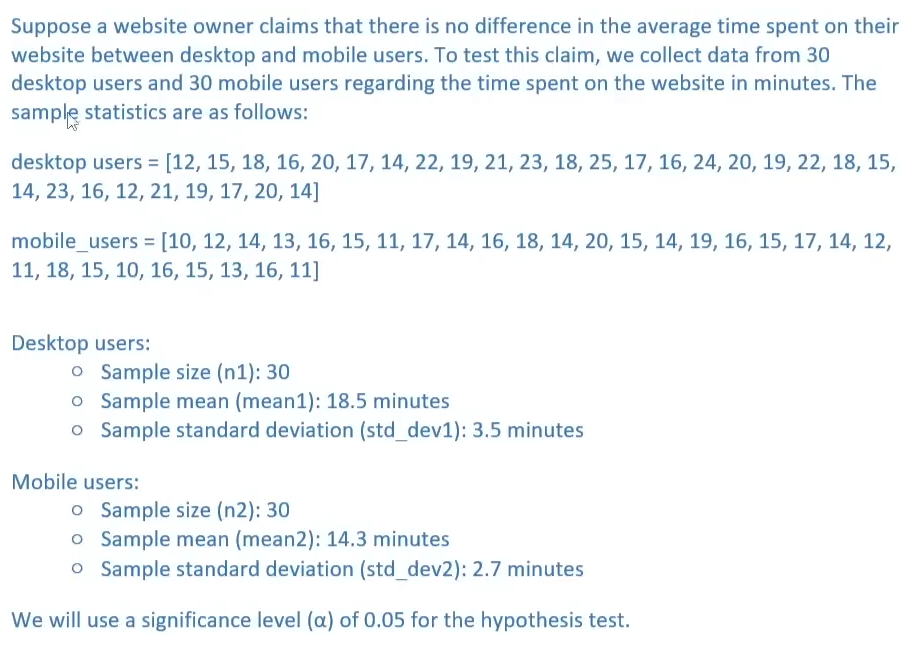

In [57]:
# H0 : mean of time spent on desktop =  mean of time spent on mobile users
# Ha : mean of time spent on desktop !=  mean of time spent on mobile users

In [58]:
# The Shapiro-Wilk test returns two values: the test statistic (W) and the p-value.
# If the p-value is greater than your chosen significance level (α = 0.05),
# you can assume the data comes from a normally distributed population.
# If the p-value is less than or equal to the significance level, the normality assumption is not met,
# and you should consider applying a data transformation or using a non-parametric test like the Mann-Whitney U test.


from scipy.stats import shapiro

# Input the data as lists
desktop_users = [12, 15, 18, 16, 20, 17, 14, 22, 19, 21, 23, 18, 25, 17, 16, 24, 20, 19, 22, 18, 15, 14, 23, 16, 12, 21, 19, 17, 20, 14]
mobile_users = [10, 12, 14, 13, 16, 15, 11, 17, 14, 16, 18, 14, 20, 15, 14, 19, 16, 15, 17, 14, 12, 11, 18, 15, 10, 16, 15, 13, 16, 11]

# Perform the Shapiro-Wilk test for both desktop and mobile users
shapiro_desktop = shapiro(desktop_users)
shapiro_mobile = shapiro(mobile_users)

print("Shapiro-Wilk test for desktop users:", shapiro_desktop)
print("Shapiro-Wilk test for mobile users:", shapiro_mobile)


Shapiro-Wilk test for desktop users: ShapiroResult(statistic=np.float64(0.9783115512411942), pvalue=np.float64(0.7791003299808725))
Shapiro-Wilk test for mobile users: ShapiroResult(statistic=np.float64(0.9714355768676655), pvalue=np.float64(0.5791606602037616))


In [59]:
# If the p-value from Levene's test is greater than your chosen significance level (α = 0.05), you can assume equal variances
#  If the p-value is less than or equal to the significance level, the assumption of equal variances is not met,
# and you should consider using Welch's t-test instead of the regular independent two-sample t-test.

from scipy.stats import levene

# Input the data as lists
desktop_users = [12, 15, 18, 16, 20, 17, 14, 22, 19, 21, 23, 18, 25, 17, 16, 24, 20, 19, 22, 18, 15, 14, 23, 16, 12, 21, 19, 17, 20, 14]
mobile_users = [10, 12, 14, 13, 16, 15, 11, 17, 14, 16, 18, 14, 20, 15, 14, 19, 16, 15, 17, 14, 12, 11, 18, 15, 10, 16, 15, 13, 16, 11]

# Perform Levene's test
levene_test = levene(desktop_users, mobile_users)
print(levene_test)


LeveneResult(statistic=np.float64(2.94395488191752), pvalue=np.float64(0.09153720526741731))


In [69]:
import scipy.stats as stats

t_statistic, p_value = stats.ttest_ind(desktop_users,mobile_users)

print("t-statistic:", t_statistic)
print("p-value:", p_value*2)

t-statistic: 4.625335930681123
p-value: 4.2845622669950513e-05


In [70]:
if p_value*2 <=0.05:
    print("Reject Null Hypothesis : mean of time spent on desktop =  mean of time spent on mobile users")
else:
    print('Fail to reject Null Hypothesis : mean of time spent on desktop !=  mean of time spent on mobile users')

Reject Null Hypothesis : mean of time spent on desktop =  mean of time spent on mobile users


In [ ]:
# or we can do this same manually by using 
# we calculate t value by using formula and degree of freedom by using n1+n2-2
t_value = 5.25
df = 30+30-2

In [61]:
from scipy.stats import t

# Set the t-value and degrees of freedom
t_value = -5.25
df = 58  # Replace this with your specific degrees of freedom

# Calculate the CDF value
cdf_value = t.cdf(t_value, df)
print(cdf_value*2)

2.2563697469332175e-06


In [62]:
if cdf_value*2 <= 0.05:
    print("Reject Null Hypothesis : mean of time spent on desktop =  mean of time spent on mobile users")
else:
    print('Fail to reject Null Hypothesis : mean of time spent on desktop !=  mean of time spent on mobile users')

Reject Null Hypothesis : mean of time spent on desktop =  mean of time spent on mobile users


In [63]:
# we work on titanic data set age column 
# mean of age male > mean of age of female

In [64]:
df

58

In [75]:
df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [81]:
pop_male = df[df['Sex']=='male']['Age'].dropna()
pop_female = df[df['Sex']=='female']['Age'].dropna()

In [82]:
sample_male = pop_male.sample(25)
sample_female = pop_female.sample(25)
alpha = 0.05

In [83]:
# H0 - Mean age of male and female are similar
# H1 - Mean age of mble is higher than female

In [84]:
# check kya ye dono sample_male and sample _female normaly distributed hai ya nhi
from scipy.stats import shapiro


# Perform the Shapiro-Wilk test for sample_male and sample_female
shapiro_male = shapiro(sample_male)
shapiro_female = shapiro(sample_female)

print("Shapiro-Wilk test for desktop users:", shapiro_male)
print("Shapiro-Wilk test for mobile users:", shapiro_female)

Shapiro-Wilk test for desktop users: ShapiroResult(statistic=np.float64(0.9405741219217885), pvalue=np.float64(0.15261967712590718))
Shapiro-Wilk test for mobile users: ShapiroResult(statistic=np.float64(0.9662552077790094), pvalue=np.float64(0.5523425319128082))


In [85]:
# check kya ye dono sample_male and sample _female ka variance same  hai ya nhi

from scipy.stats import levene


# Perform Levene's test
levene_test = levene(sample_male,sample_female)
print(levene_test)

LeveneResult(statistic=np.float64(2.0658873538788516), pvalue=np.float64(0.15711446722693193))


In [90]:
# to direct calculate p_value 
import scipy.stats as stats

t_statistic, p_value = stats.ttest_ind(sample_male,sample_female)

print("t-statistic:", t_statistic)
print("p-value:", p_value/2)

t-statistic: 1.068704262848767
p-value: 0.14527408811182219


In [91]:
if p_value/2 <= 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to reject Null Hypothesis")

Fail to reject Null Hypothesis


#### Paired t-test (dependent two-sample t-test):

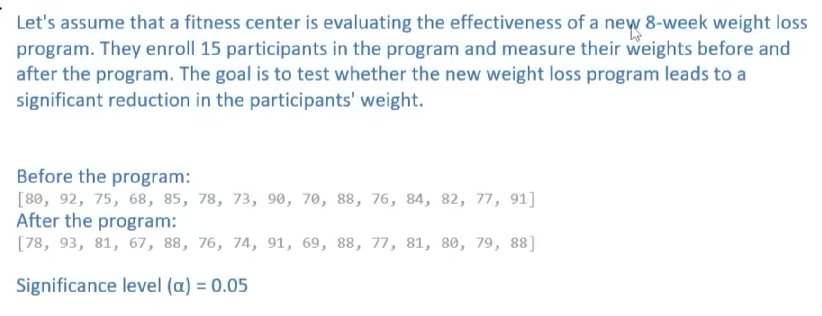